# OLS Linear Regression
OLS: ordinary least squares

## Example 1: does year of education increase income?
In the nls97 dataset, there is a variable called `highestgradecompleted.` It measures the highest grade of regular school the respondent has completed, typically ranging from 0 (no formal schooling) to 20 (completion of 8 or more years of higher education).

Regression equation:
$I_i = a + bE_i + \mu$, where $I_i$ represents income of individual $i$, and $E_i$ represents the years of formal school education.
Hypotheses:
- $H_0$: $b=0$
- $H_1$: $b \neq 0$

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("../05-data_cleaning/data/nls97.csv")
df.head()

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
1,100139,Male,9,1983,12.0,Married,2.0,0.0,120000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
2,100284,Male,11,1984,7.0,Never-married,1.0,0.0,58000.0,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
3,100292,Male,4,1982,NaN,NaN,NaN,NaN,NaN,NaN,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,NaN,NaN,NaN,NaN
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled


### Prepare data and inspect data
- Cast the variables to numeric
- Drop missing values
- Remove outliers

In [5]:
df['school_year'] = pd.to_numeric(df['highestgradecompleted'], errors='coerce')
df.dropna(subset=['school_year', 'wageincome'], inplace=True)
df['school_year'] = df['school_year'].astype(int)

In [6]:
df[['school_year', 'wageincome']].describe()

,school_year,wageincome
count,5051.000000,5051.000000
mean,14.442289,49647.321323
std,4.082659,40764.982227
min,6.000000,0.000000
25%,12.000000,25000.000000
50%,14.000000,40000.000000
75%,16.000000,62000.000000
max,95.000000,235884.000000


<Axes: xlabel='school_year', ylabel='wageincome'>

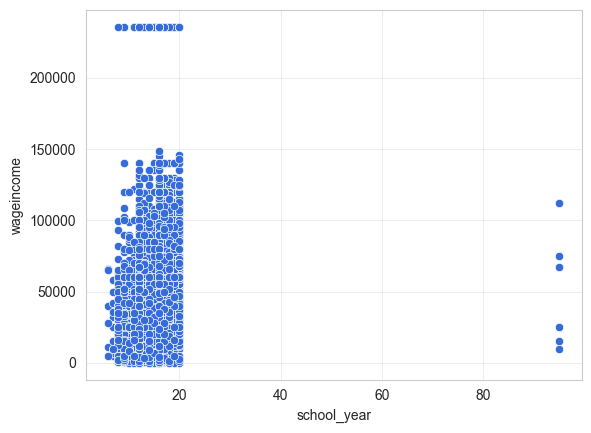

In [7]:
sns.set_style('whitegrid')
sns.scatterplot(data=df, x="school_year", y="wageincome")

We observe there some outliers with school year 95 and very high wageincome. They are the same values, so let's assume they are errors and remove them.

In [8]:
df = df[(df['school_year']<40) & (df['wageincome']<200000)].copy()

In [29]:
df[['school_year', 'wageincome']].describe()

,school_year,wageincome
count,4924.000000,4924.000000
mean,14.278838,45069.588952
std,2.972012,28801.769144
min,6.000000,0.000000
25%,12.000000,25000.000000
50%,14.000000,40000.000000
75%,16.000000,60000.000000
max,20.000000,149000.000000


<Axes: xlabel='school_year', ylabel='wageincome'>

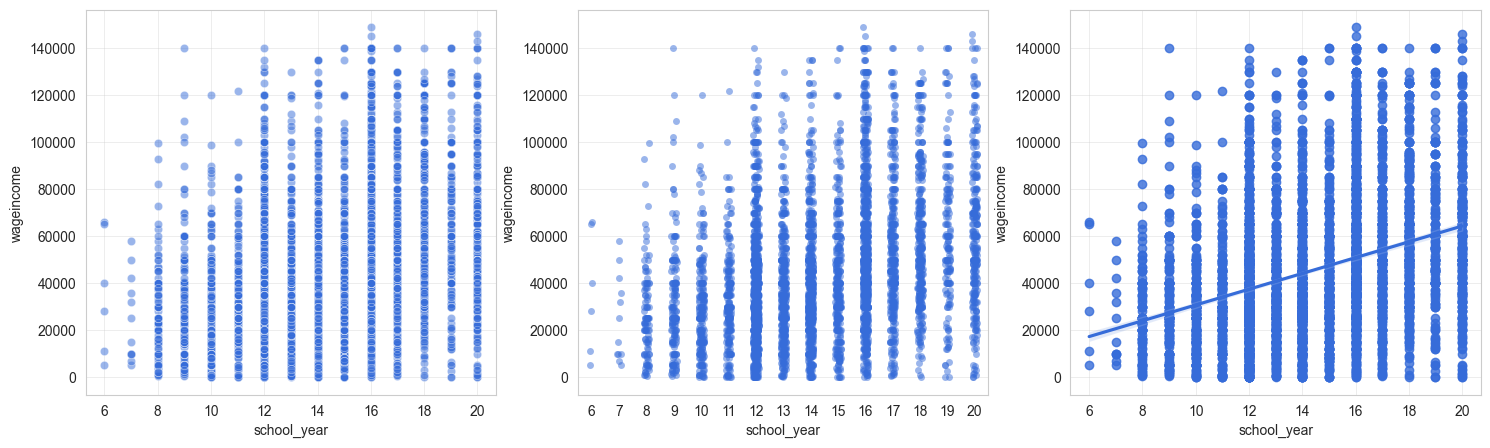

In [63]:
sns.set_style('whitegrid')
fig, axes=plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.scatterplot(data=df, x="school_year", y="wageincome", ax=axes[0], alpha=0.5)
sns.stripplot(data=df, x="school_year", y="wageincome", ax=axes[1], alpha=0.5, jitter=True)
sns.regplot(data=df, x='school_year', y='wageincome', ax=axes[2])

### Run regression


In [9]:

X = df["school_year"]
y = df["wageincome"]

# Add constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             wageincome   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     673.0
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          3.50e-139
Time:                        16:07:00   Log-Likelihood:                -57231.
No. Observations:                4924   AIC:                         1.145e+05
Df Residuals:                    4922   BIC:                         1.145e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -2921.5922   1889.600     -1.546      

### Interpretation
- $a=13580$, indicating people with no formal school year education still have income on average of \\$13,580.  This does not mean everyone who does not have education still earn \$13,580, it simply is the model intercept. (I usually try not to interpret the value of a).
- $b=2497.20$, indicating each extra year of school education increases income by \$2,497.
- $p < 0.001$ (in fact, p value can be access using `model.pvalues` and $p=6.85 \times 10^{-73}$, extremely small, so the coefficient $b$ is statistically significant.
- R-square: Proportion of variation in income explained by education

In [10]:
alpha = 0.05

if model.pvalues["school_year"] < alpha:
    print("Reject H0: education significantly affects income")
else:
    print("Fail to reject H0")

Reject H0: education significantly affects income


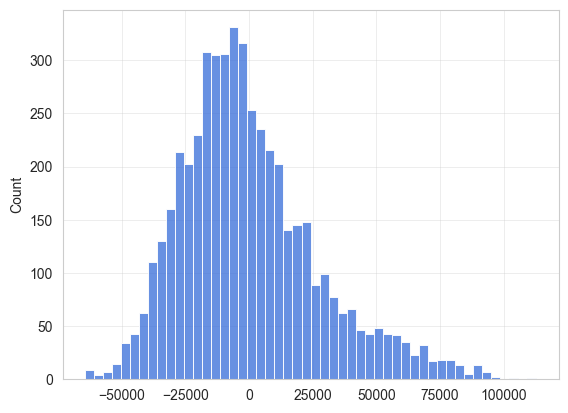

In [11]:
g0=sns.histplot(data=model.resid, bins=50)

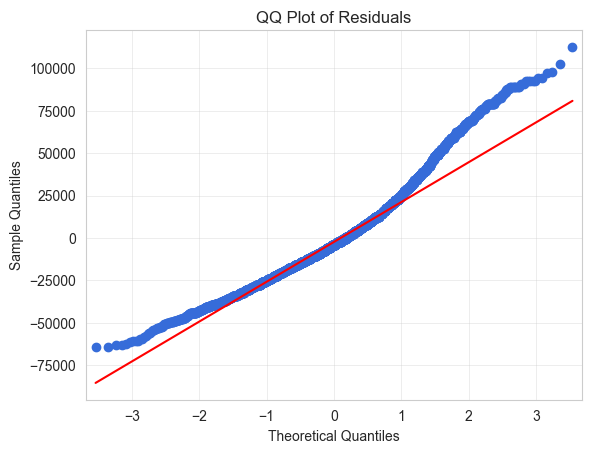

In [12]:
g1=sm.qqplot(model.resid, line='q')
plt.title("QQ Plot of Residuals")
plt.show()

## Example 2: multiple regression

Let's say, we also suspect income might be related to other variables.

${Income}_i = \beta_0 + \beta_1{Education}_i + \beta_2{Gender}_i+\beta{GPA}_i+\epsilon$


In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm


df = pd.read_csv("../05-data_cleaning/data/nls97.csv")

numeric_vars = ['wageincome', 'highestgradecompleted', 'gpaoverall']

for var in numeric_vars:
    df[var] = pd.to_numeric(df[var], errors='coerce')

df.dropna(subset=numeric_vars + ['gender'], inplace=True)

df.head()

,personid,gender,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,...,colenrfeb13,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17
0,100061,Female,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
4,100583,Male,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
5,100833,Male,1,1981,12.0,Married,2.0,0.0,39000.0,1 to 3 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
7,101089,Male,4,1980,13.0,Never-married,NaN,NaN,36000.0,4 to 6 hours a week,...,1. Not enrolled,1. Not enrolled,2. 2-year college,2. 2-year college,2. 2-year college,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled
11,101288,Female,7,1980,20.0,Married,2.0,0.0,50000.0,10 hours or more a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,3. 4-year college,3. 4-year college,3. 4-year college,3. 4-year college,3. 4-year college


In [117]:
df[numeric_vars].describe()

,wageincome,highestgradecompleted,gpaoverall
count,3635.0,3635.0,3635.0
mean,51708.543603851445,14.766712517193948,288.1171939477304
std,41607.88518663095,3.894317021931237,58.97329245280268
min,0.0,6.0,42.0
25%,26000.0,12.0,250.0
50%,42000.0,15.0,292.0
75%,65000.0,17.0,331.0
max,235884.0,95.0,411.0


In [14]:
df = df[(df['highestgradecompleted']<40) & (df['wageincome']<200000)].copy()
df = pd.get_dummies(data=df, columns=['gender'], drop_first=True, dtype=int)
df.head()

,personid,birthmonth,birthyear,highestgradecompleted,maritalstatus,childathome,childnotathome,wageincome,weeklyhrscomputer,weeklyhrstv,...,colenroct13,colenrfeb14,colenroct14,colenrfeb15,colenroct15,colenrfeb16,colenroct16,colenrfeb17,colenroct17,gender_Male
0,100061,5,1980,13.0,Married,4.0,0.0,12500.0,10 hours or more a week,11 to 20 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,0
4,100583,1,1980,13.0,Married,4.0,0.0,30000.0,Less than 1 hour a week,3 to 10 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1
5,100833,1,1981,12.0,Married,2.0,0.0,39000.0,1 to 3 hours a week,3 to 10 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1
7,101089,4,1980,13.0,Never-married,NaN,NaN,36000.0,4 to 6 hours a week,Less than 2 hours per week,...,1. Not enrolled,2. 2-year college,2. 2-year college,2. 2-year college,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,1
11,101288,7,1980,20.0,Married,2.0,0.0,50000.0,10 hours or more a week,3 to 10 hours a week,...,1. Not enrolled,1. Not enrolled,1. Not enrolled,1. Not enrolled,3. 4-year college,3. 4-year college,3. 4-year college,3. 4-year college,3. 4-year college,0


In [15]:
# run regression

X = df[["highestgradecompleted", 'gpaoverall','gender_Male']].rename(columns={
    "highestgradecompleted":"school_year",
    "gpaoverall":"GPA",
    "gender_Male":"is_male"
})
y = df["wageincome"]

# Add constant (intercept)
X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             wageincome   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     287.7
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          4.34e-167
Time:                        16:07:28   Log-Likelihood:                -40965.
No. Observations:                3536   AIC:                         8.194e+04
Df Residuals:                    3532   BIC:                         8.196e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -2.65e+04   2755.365     -9.619      

The large condition number could caused by

In [120]:
from scipy.stats import pearsonr
from itertools import combinations
for var1, var2 in combinations(['highestgradecompleted',"gpaoverall","gender_Male"], 2):
    corr, p_value = pearsonr(df[var1], df[var2])
    print(f"{var1} + {var2}: {corr=:.3f}, {p_value=:.5f}")

highestgradecompleted + gpaoverall: corr=0.505, p_value=0.00000
highestgradecompleted + gender_Male: corr=-0.164, p_value=0.00000
gpaoverall + gender_Male: corr=-0.185, p_value=0.00000


We can also check VIFs.

In [121]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

print(vif_data)

      variable                VIF
0        const  39.64926859324697
1  school_year   1.35197735604247
2          GPA 1.3623289567701544
3      is_male 1.0425220169559486


Inspect residue

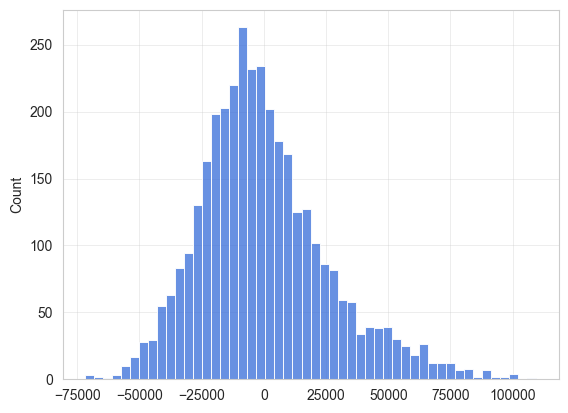

In [17]:
g2=sns.histplot(data=model2.resid, bins=50)

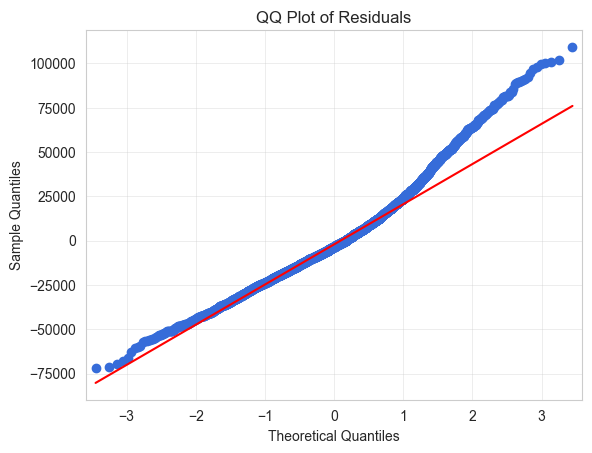

In [18]:
g3=sm.qqplot(model2.resid, line='q')
plt.title("QQ Plot of Residuals")
plt.show()

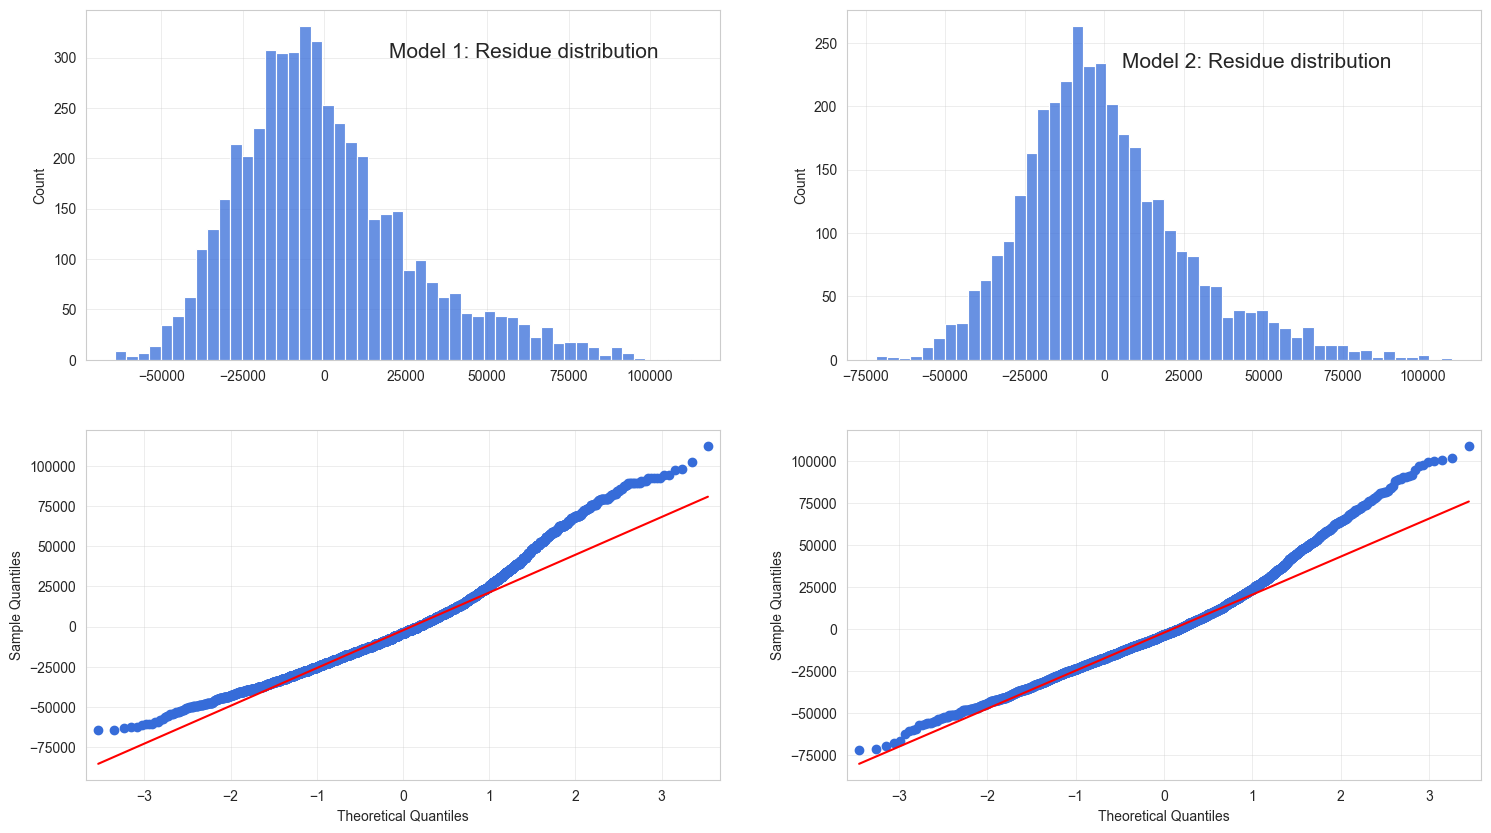

In [36]:
fig, axes=plt.subplots(2, 2, figsize=(18, 10))

g0=sns.histplot(data=model.resid, bins=50, ax=axes.flat[0])
g0.text(x=20_000, y=300, s="Model 1: Residue distribution", fontsize=15)
g1=sm.qqplot(model.resid, line='q', ax=axes.flat[2])

g2=sns.histplot(data=model2.resid, bins=50,ax=axes.flat[1])
g2.text(x=5_500, y=230, s="Model 2: Residue distribution", fontsize=15)
g3=sm.qqplot(model2.resid, line='q', ax=axes.flat[3])